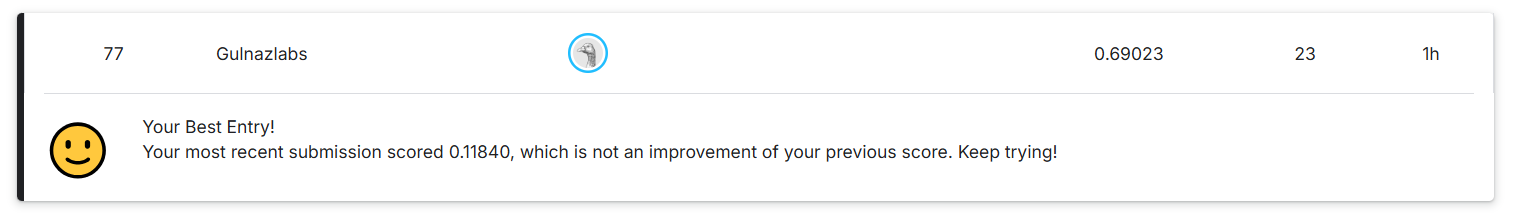

In [ ]:
# Установка Kaggle API
!pip install kaggle -q

!mkdir -p ~/.kaggle

!echo "..мой токен..." > ~/.kaggle/access_token

!chmod 600 ~/.kaggle/access_token

!cat ~/.kaggle/access_token

In [2]:
!pip install kagglehub

In [3]:
import kagglehub

path = kagglehub.competition_download(
    "signal-types-classification"
)

print("Путь к файлам:", path)

100%|██████████| 13.2M/13.2M [00:00<00:00, 111MB/s]

Extracting files...


Путь к файлам: /root/.cache/kagglehub/competitions/signal-types-classification


In [4]:
import os

os.listdir(path)

['Run200_Wave_0_1.txt', 'test-dataset.ipynb', 'Description.pdf']

In [5]:
# Импорт библиотек

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


In [6]:
file_path = os.path.join(path, "Run200_Wave_0_1.txt")

df = pd.read_csv(
    file_path,
    sep=" ",
    header=None,
    skipinitialspace=True
)

print(df.shape)

display(df.head())

df.info()

(23479, 505)


,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14822,14815,14815,14817,14819,14820,14822,14820,14819,NaN
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14817,14824,14822,14824,14819,14820,14819,14822,14820,NaN
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14821,14820,14820,14818,14821,14823,14820,14820,14821,NaN
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14826,14822,14821,14820,14828,14820,14822,14823,14822,NaN
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14823,14828,14824,14820,14824,14824,14822,14825,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 505 entries, 0 to 504
dtypes: float64(1), int64(504)
memory usage: 90.5 MB


Исходный датасет содержит 23 479 объектов и 505 признаков.

Первые четыре столбца являются метаданными и не описывают форму сигнала, поэтому они были исключены из дальнейшего анализа.  
Также последний столбец содержит пустые значения, поэтому он был удалён.

После удаления служебных и некорректных столбцов в датасете остались только временные отсчёты сигналов, которые я буду далее использовать для EDA, предобработки, извлечения признаков и кластеризации.

In [7]:
# Data loading
dataset = pd.read_csv(os.path.join(path, 'Run200_Wave_0_1.txt'),
                      sep=' ',
                      header=None,
                      skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [8]:
# EDA

print("Размер датасета:", dataset.shape)
print("Количество сигналов:", dataset.shape[0])
print("Количество временных отсчетов:", dataset.shape[1])

print("\nПропуски:", dataset.isnull().sum().sum())
print("Дубликаты:", dataset.duplicated().sum())

display(dataset.describe().T.head())

Размер датасета: (23479, 500)
Количество сигналов: 23479
Количество временных отсчетов: 500

Пропуски: 0
Дубликаты: 0


,count,mean,std,min,25%,50%,75%,max
0,23479.0,14822.972316,2.805884,14812.0,14821.0,14823.0,14824.0,14834.0
1,23479.0,14822.958474,2.833516,14812.0,14821.0,14823.0,14824.0,14835.0
2,23479.0,14822.970016,2.840755,14812.0,14821.0,14823.0,14825.0,14834.0
3,23479.0,14822.989991,2.852066,14811.0,14821.0,14823.0,14825.0,14835.0
4,23479.0,14823.003961,2.833412,14812.0,14821.0,14823.0,14825.0,14834.0


Text(0, 0.5, 'bit ADC')

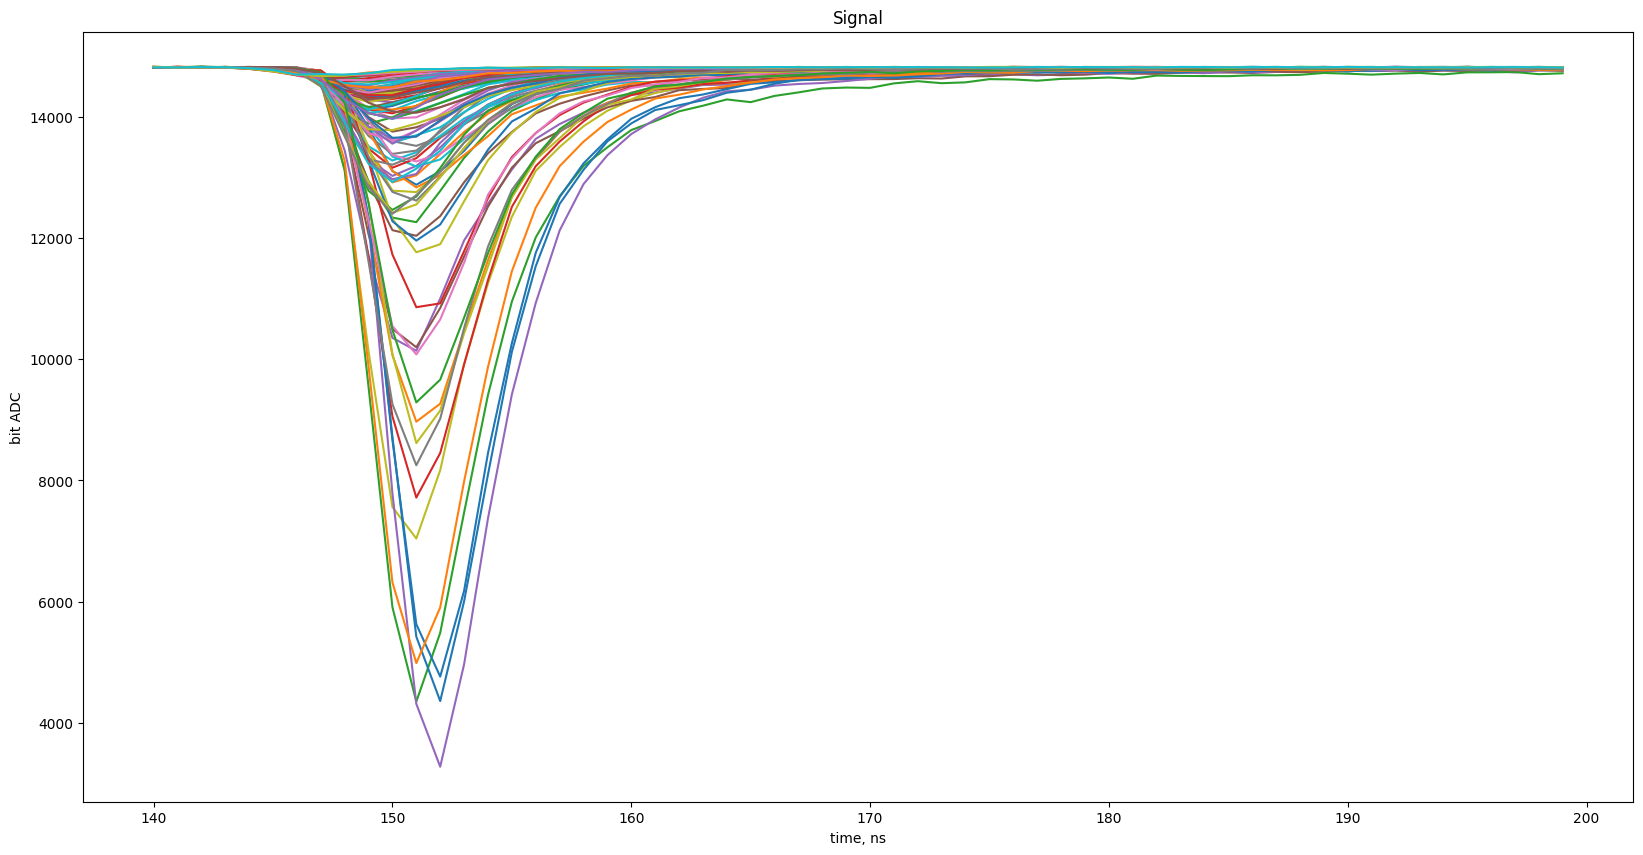

In [9]:
N=range(0,100)
ax = dataset.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

На графике видно, что основные импульсы сигналов расположены примерно в области 150-155 нс и имеют отрицательную форму относительно базовой линии. Сигналы различаются по амплитуде и форме хвоста, что может быть полезно для последующей кластеризации. Поэтому на следующем этапе требуется выполнить baseline correction и инверсию сигнала.

Text(0, 0.5, 'bit ADC')

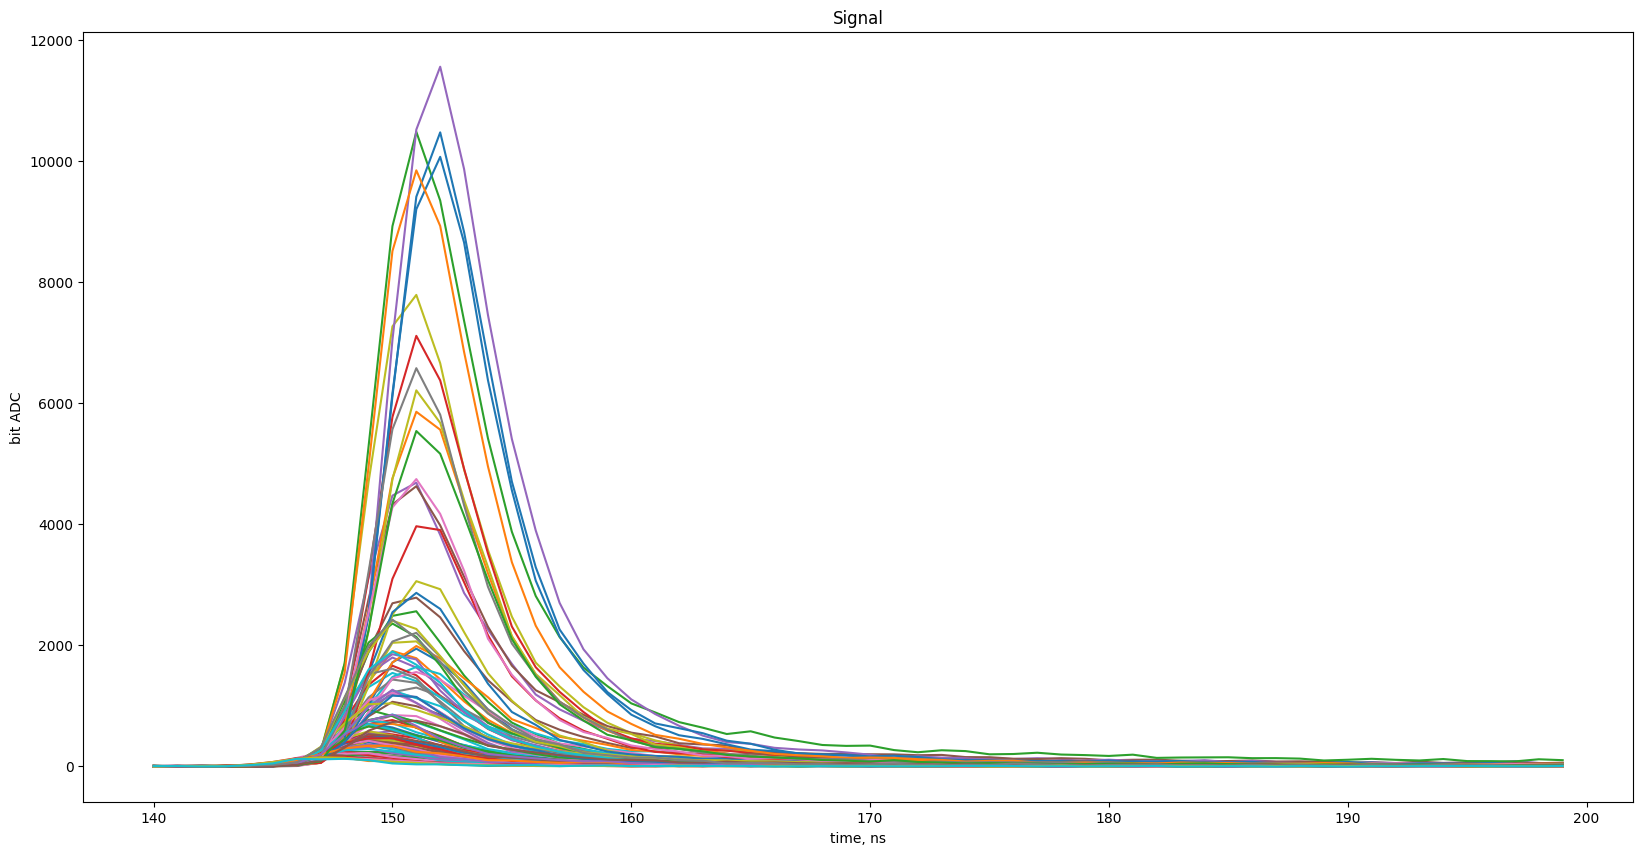

In [10]:
# Инверсия сигналов и приведение импульсов к положительной форме

ax = (2**14-dataset.T[N]-1560)[140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

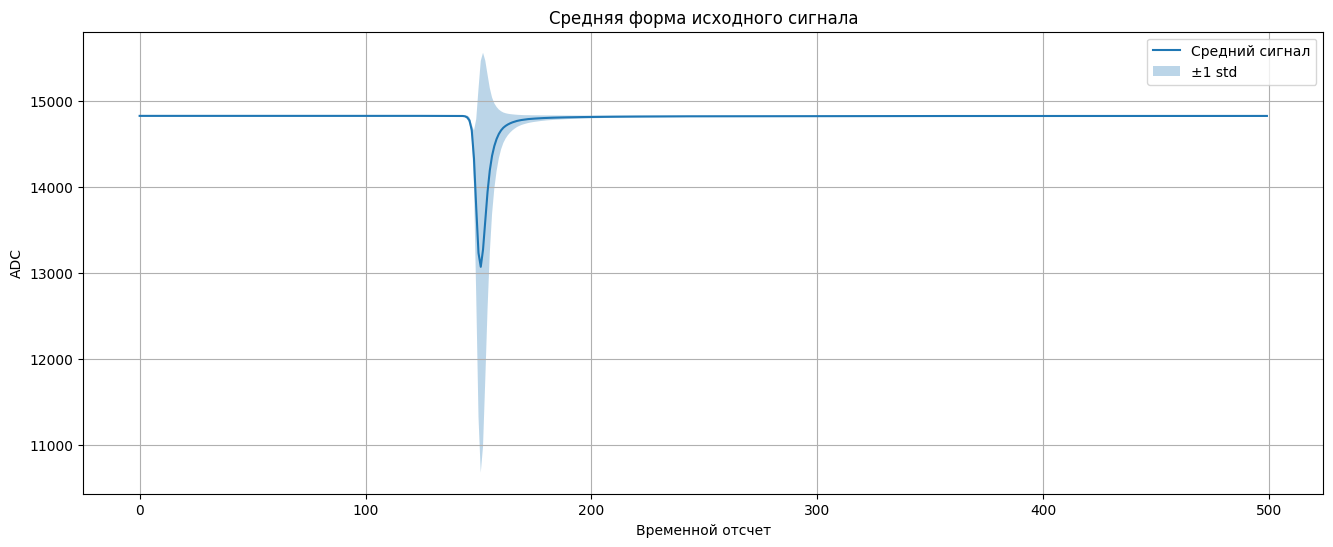

In [13]:
# Средняя форма сигнала и разброс значений

x_axis = np.arange(dataset.shape[1])

mean_signal = dataset.mean(axis=0).values
std_signal = dataset.std(axis=0).values

plt.figure(figsize=(16, 6))

plt.plot(x_axis, mean_signal, label="Средний сигнал")
plt.fill_between(
    x_axis,
    mean_signal - std_signal,
    mean_signal + std_signal,
    alpha=0.3,
    label="±1 std"
)

plt.title("Средняя форма исходного сигнала")
plt.xlabel("Временной отсчет")
plt.ylabel("ADC")
plt.legend()
plt.grid(True)
plt.show()

На графике представлена средняя форма исходного сигнала по всем объектам датасета, а также область разброса значений в пределах одного стандартного отклонения.

Видно, что до появления импульса сигнал находится около стабильного базового уровня. Основной импульс расположен примерно в области 145-160 временного отсчёта и имеет отрицательную форму, то есть значение ADC резко уменьшается относительно baseline.

Наибольший разброс наблюдается именно в области импульса. Это означает, что сигналы заметно различаются по амплитуде и форме восстановления после пика. Эти различия могут быть полезны для последующей кластеризации.

Полученный график подтверждает необходимость предобработки: коррекции базовой линии и инверсии сигнала, чтобы импульсы стали положительными и их признаки было удобнее рассчитывать.

In [14]:
# Baseline correction + инверсия сигнала
signals_raw = dataset.copy()

baseline_window = list(range(0, 100))

baseline = signals_raw.iloc[:, baseline_window].mean(axis=1)

signals_processed = -(signals_raw.sub(baseline, axis=0))

display(signals_processed.head())

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,1.13,-1.87,-2.87,-0.87,3.13,1.13,-2.87,-0.87,1.13,1.13,...,-6.87,-0.87,6.13,6.13,4.13,2.13,1.13,-0.87,1.13,2.13
1,2.47,0.47,2.47,-3.53,-1.53,0.47,2.47,0.47,-0.53,1.47,...,-5.53,5.47,-1.53,0.47,-1.53,3.47,2.47,3.47,0.47,2.47
2,1.92,1.92,-0.08,-3.08,1.92,-2.08,-2.08,2.92,-1.08,-2.08,...,1.92,0.92,1.92,1.92,3.92,0.92,-1.08,1.92,1.92,0.92
3,-5.24,0.76,4.76,-1.24,-1.24,0.76,2.76,0.76,-1.24,2.76,...,-1.24,-3.24,0.76,1.76,2.76,-5.24,2.76,0.76,-0.24,0.76
4,-1.57,6.43,-1.57,0.43,-5.57,1.43,-1.57,-2.57,5.43,0.43,...,1.43,1.43,-1.57,-6.57,-2.57,1.43,-2.57,-2.57,-0.57,-3.57


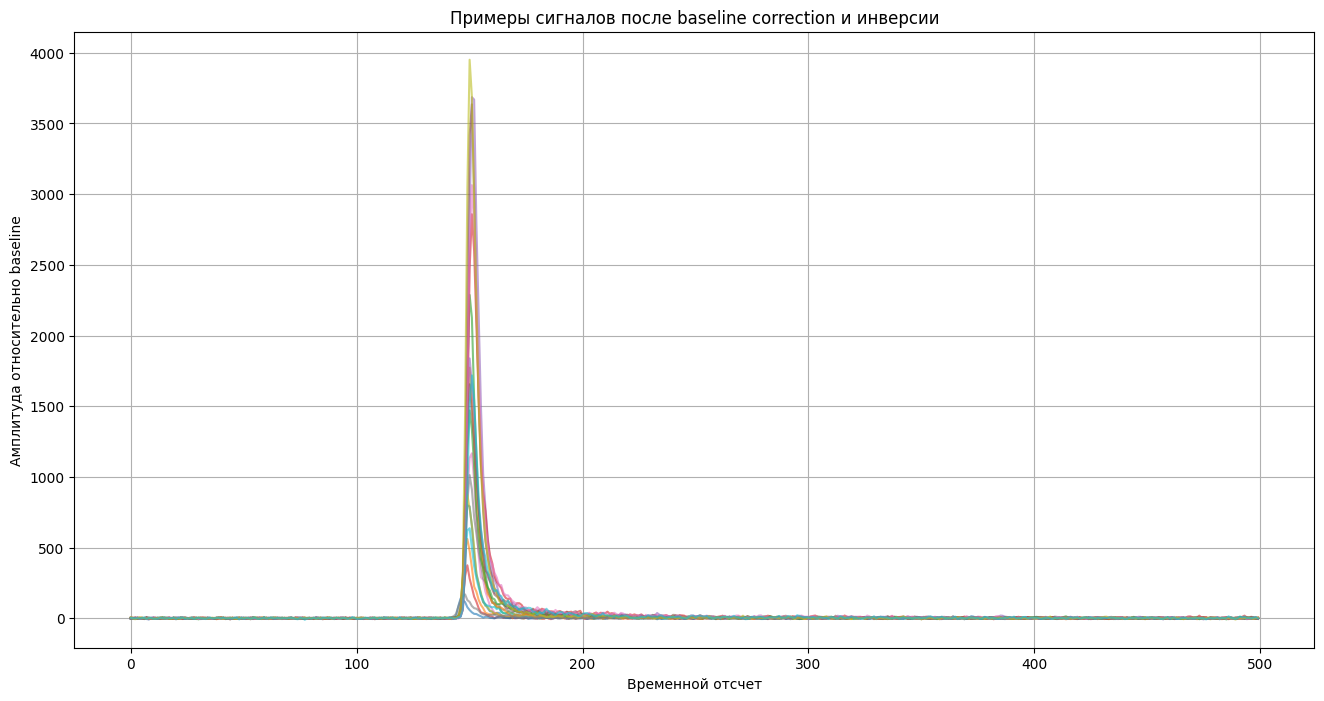

In [15]:
# Визуальная проверка предобработанных сигналов

random_indices = np.random.choice(signals_processed.index, size=20, replace=False)

plt.figure(figsize=(16, 8))

for idx in random_indices:
    plt.plot(x_axis, signals_processed.loc[idx].values, alpha=0.6)

plt.title("Примеры сигналов после baseline correction и инверсии")
plt.xlabel("Временной отсчет")
plt.ylabel("Амплитуда относительно baseline")
plt.grid(True)
plt.show()

После предобработки импульсы стали положительными и располагаются примерно в одной временной области.  
Основной пик большинства сигналов находится около 150 временного отсчёта.

Сигналы различаются по амплитуде и форме хвоста после пика. Эти различия важны для дальнейшего анализа, так как они могут отражать разные типы частиц или аномальные события.

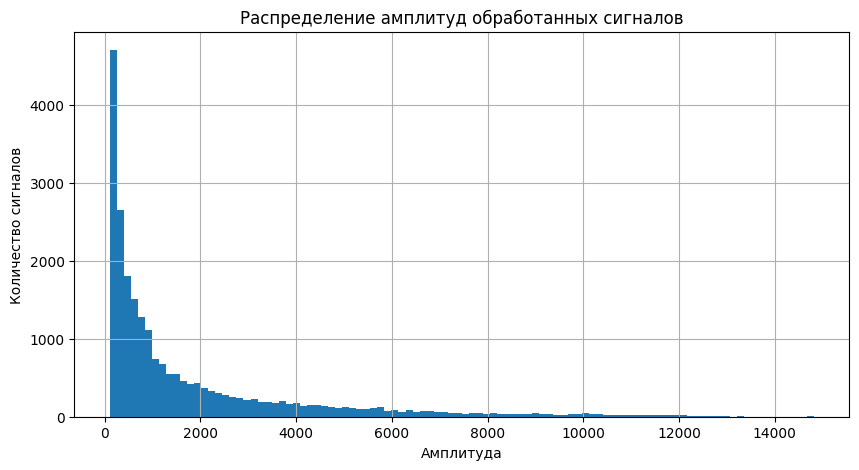

,0
count,23479.000000
mean,1835.103314
std,2389.301353
min,104.230000
25%,308.220000
50%,812.720000
75%,2315.270000
max,14824.820000


In [16]:
# Распределение амплитуд после предобработки

amplitudes = signals_processed.max(axis=1)

plt.figure(figsize=(10, 5))
plt.hist(amplitudes, bins=100)
plt.title("Распределение амплитуд обработанных сигналов")
plt.xlabel("Амплитуда")
plt.ylabel("Количество сигналов")
plt.grid(True)
plt.show()

display(amplitudes.describe())

Распределение амплитуд имеет выраженную правостороннюю асимметрию: большинство сигналов имеют относительно небольшую амплитуду, при этом присутствуют сигналы с очень большими значениями амплитуды.

Медианная амплитуда заметно ниже среднего значения, что также указывает на наличие длинного правого хвоста распределения.  
Такая структура данных говорит о том, что при дальнейшем моделировании желательно использовать признаки формы сигнала и масштабирование, устойчивое к выбросам.

In [17]:
# Feature Engineering
# На этом этапе из временного ряда извлекаются числовые признаки, которые описывают амплитуду, площадь импульса, положение максимума и форму хвостовой части сигнала

signals = signals_processed.copy()

features = pd.DataFrame(index=signals.index)

eps = 1e-9

# Базовые статистики
features["amplitude"] = signals.max(axis=1)
features["min_value"] = signals.min(axis=1)
features["mean"] = signals.mean(axis=1)
features["std"] = signals.std(axis=1)

# Положение максимума
features["peak_pos"] = signals.values.argmax(axis=1)

# Интегралы
features["total_integral"] = signals.sum(axis=1)

# Области сигнала выбраны по результатам EDA: основной пик находится примерно около 145-160 отсчета
features["pre_peak_integral"] = signals.iloc[:, 120:145].sum(axis=1)
features["peak_integral"] = signals.iloc[:, 145:160].sum(axis=1)
features["fast_integral"] = signals.iloc[:, 145:170].sum(axis=1)
features["tail_integral"] = signals.iloc[:, 170:230].sum(axis=1)
features["long_tail_integral"] = signals.iloc[:, 230:350].sum(axis=1)

# PSD-признаки
features["tail_to_total"] = features["tail_integral"] / (features["total_integral"] + eps)
features["fast_to_total"] = features["fast_integral"] / (features["total_integral"] + eps)
features["tail_to_fast"] = features["tail_integral"] / (features["fast_integral"] + eps)
features["peak_to_total"] = features["peak_integral"] / (features["total_integral"] + eps)

# Дополнительные признаки формы
features["integral_to_amplitude"] = features["total_integral"] / (features["amplitude"] + eps)
features["tail_to_amplitude"] = features["tail_integral"] / (features["amplitude"] + eps)

# Признаки поздней активности для анализа возможных аномалий
late_window = signals.iloc[:, 430:500]

features["late_max"] = late_window.max(axis=1)
features["late_integral"] = late_window.sum(axis=1)
features["late_max_to_amplitude"] = features["late_max"] / (features["amplitude"] + eps)
features["late_integral_to_total"] = features["late_integral"] / (features["total_integral"] + eps)

# Обработка возможных inf/nan
features = features.replace([np.inf, -np.inf], np.nan)
features = features.fillna(features.median())

print("Размер таблицы признаков:", features.shape)
display(features.head())

Размер таблицы признаков: (23479, 21)


,amplitude,min_value,mean,std,peak_pos,total_integral,pre_peak_integral,peak_integral,fast_integral,tail_integral,...,tail_to_total,fast_to_total,tail_to_fast,peak_to_total,integral_to_amplitude,tail_to_amplitude,late_max,late_integral,late_max_to_amplitude,late_integral_to_total
0,530.13,-8.87,9.228,46.208472,149,4614.0,23.25,3242.95,3530.25,644.8,...,0.139749,0.765117,0.182650,0.702850,8.703526,1.216305,6.13,46.1,0.011563,0.009991
1,1901.47,-5.53,24.696,163.272112,150,12348.0,25.75,10734.05,11330.75,553.2,...,0.044801,0.917618,0.048823,0.869295,6.493923,0.290933,7.47,86.9,0.003929,0.007038
2,2557.92,-8.08,33.910,225.369832,151,16955.0,14.00,14880.80,15870.00,533.2,...,0.031448,0.936007,0.033598,0.877664,6.628432,0.208451,7.92,71.4,0.003096,0.004211
3,564.76,-8.24,9.316,50.120565,149,4658.0,15.00,3433.40,3767.00,540.6,...,0.116058,0.808716,0.143509,0.737097,8.247751,0.957221,5.76,33.2,0.010199,0.007128
4,1793.43,-6.57,23.212,156.545416,150,11606.0,-10.25,10361.45,10958.75,474.8,...,0.040910,0.944231,0.043326,0.892767,6.471398,0.264744,5.43,24.1,0.003028,0.002077


Для каждого сигнала были рассчитаны следующие группы признаков:

- базовые статистики: амплитуда, минимум, среднее значение, стандартное отклонение;
- временной признак: положение максимума сигнала;
- интегральные признаки по разным областям импульса;
- PSD-признаки, описывающие отношение хвостовой части к полной и быстрой компонентам сигнала;
- признаки поздней активности, которые могут указывать на аномальные события.

В результате Feature Engineering была сформирована таблица признаков размером 23 479 × 21.  
Каждому исходному сигналу теперь соответствует набор числовых характеристик, описывающих его форму.

In [18]:
# Статистический анализ полученных признаков
display(features.describe().T)

,count,mean,std,min,25%,50%,75%,max
amplitude,23479.0,1835.103314,2389.301353,104.230000,308.220000,812.720000,2315.270000,14824.820000
min_value,23479.0,-7.746253,1.234035,-15.520000,-8.530000,-7.670000,-6.880000,-3.970000
mean,23479.0,26.281382,32.194186,0.766000,4.876000,12.484000,34.633000,226.132000
std,23479.0,161.693850,208.973628,10.231617,27.740063,72.155612,204.672726,1484.918725
peak_pos,23479.0,149.628604,2.489996,145.000000,149.000000,150.000000,151.000000,472.000000
total_integral,23479.0,13140.691128,16097.092930,383.000000,2438.000000,6242.000000,17316.500000,113066.000000
pre_peak_integral,23479.0,6.829039,19.176516,-86.500000,-5.250000,5.500000,16.000000,229.250000
peak_integral,23479.0,10710.831415,13585.435770,533.150000,1908.575000,4912.950000,13692.975000,97347.650000
fast_integral,23479.0,11619.427190,14655.767851,560.250000,2074.625000,5346.250000,14923.125000,105454.250000
tail_integral,23479.0,946.849406,1115.793954,-90.400000,182.500000,502.600000,1323.400000,8102.400000


Статистическое описание признаков показывает, что амплитуда и интегральные признаки имеют сильно скошенные распределения: большинство сигналов имеют относительно небольшие значения, но присутствуют отдельные сигналы с большой амплитудой и большой интегральной площадью.

Положение максимума peak_pos для большинства сигналов находится около 149-151 временного отсчёта, что подтверждает стабильное положение основного импульса.  
При этом встречаются отдельные значения с сильно отличающимся положением максимума, что может указывать на аномальные сигналы.

PSD-признаки tail_to_total и tail_to_fast имеют заметный разброс, поэтому они могут быть полезны для разделения сигналов по форме хвостовой части.

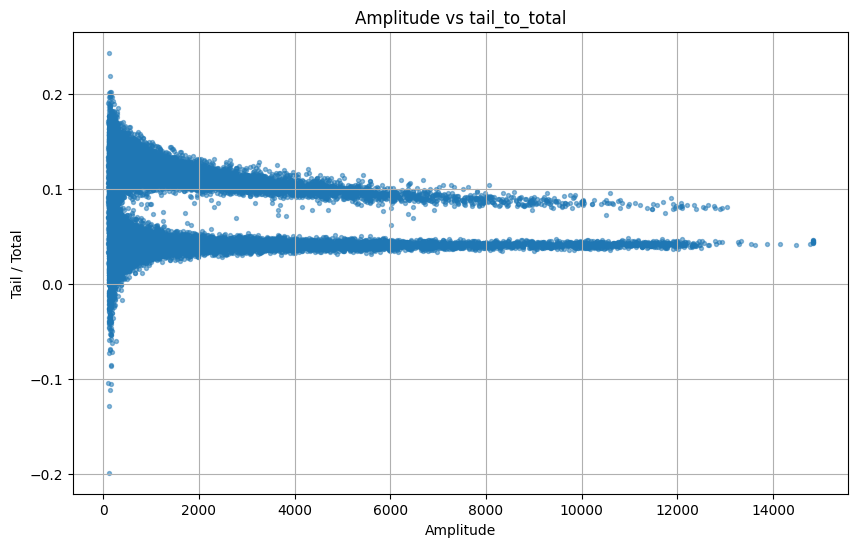

In [19]:
# Анализ зависимости амплитуды от доли хвостовой компоненты

plt.figure(figsize=(10, 6))

plt.scatter(
    features["amplitude"],
    features["tail_to_total"],
    s=8,
    alpha=0.5
)

plt.title("Amplitude vs tail_to_total")
plt.xlabel("Amplitude")
plt.ylabel("Tail / Total")
plt.grid(True)
plt.show()

На графике видно, что сигналы формируют две выраженные области по признаку "tail_to_total".  
Одна группа имеет меньшую долю хвостовой компоненты, другая - большую.

При малых амплитудах наблюдается больший разброс значений "tail_to_total", что может быть связано со слабыми или пограничными сигналами.  
В целом этот график показывает, что отношение хвостовой части к полной площади сигнала является информативным признаком для кластеризации.

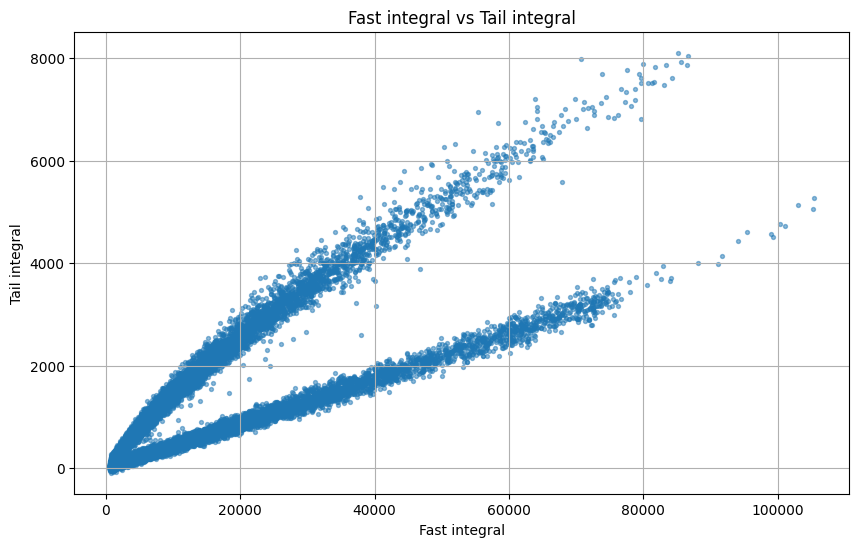

In [20]:
# Анализ быстрой и хвостовой компонент сигнала

plt.figure(figsize=(10, 6))

plt.scatter(
    features["fast_integral"],
    features["tail_integral"],
    s=8,
    alpha=0.5
)

plt.title("Fast integral vs Tail integral")
plt.xlabel("Fast integral")
plt.ylabel("Tail integral")
plt.grid(True)
plt.show()

График "fast_integral vs tail_integral" показывает две хорошо различимые ветви.  
Это означает, что при одинаковой или близкой величине быстрой компоненты сигналы могут иметь разную выраженность хвоста.

Такое разделение хорошо соответствует физической идее PSD-анализа: разные типы частиц могут давать импульсы с различной долей хвостовой компоненты.  
Поэтому признаки, связанные с fast- и tail-интегралами, являются ключевыми для итоговой модели кластеризации.

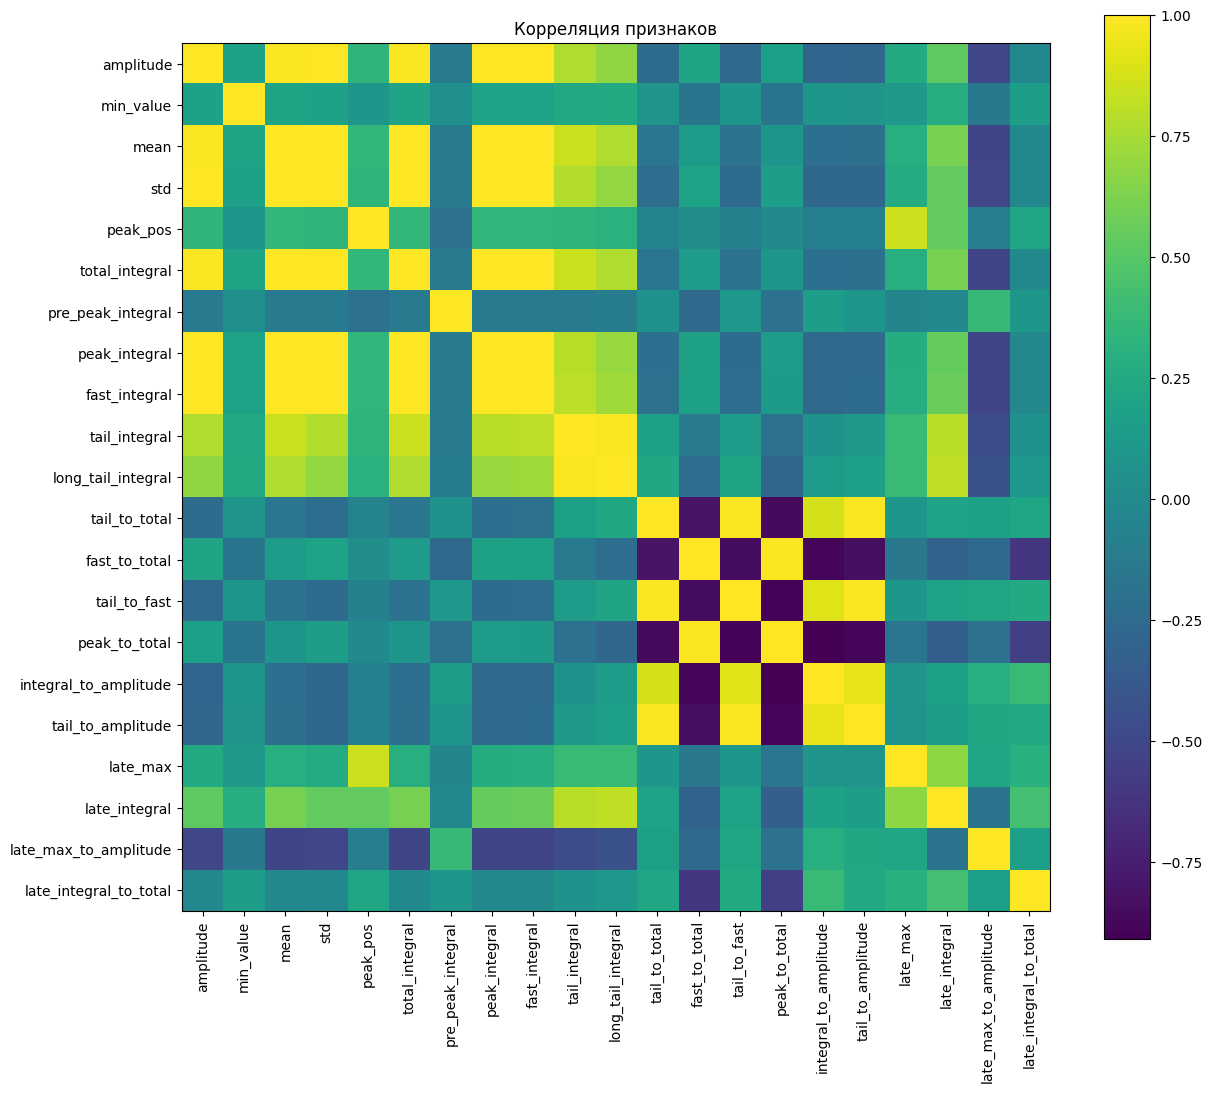

In [21]:
# корреляция признаков

corr = features.corr()

plt.figure(figsize=(14, 12))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Корреляция признаков")
plt.show()

Корреляционная матрица показывает, что часть признаков сильно связана между собой.  
Например, амплитуда, полная интегральная площадь, интеграл пика и fast-интеграл имеют высокую положительную корреляцию, так как все они описывают общую интенсивность сигнала.

При этом PSD-признаки (tail_to_total, tail_to_fast, integral_to_amplitude) несут дополнительную информацию о форме импульса и не полностью дублируют амплитудные признаки.

На основе этого анализа для тестовой финальной модели были выбраны именно PSD-признаки, так как они лучше отражают различия в форме сигналов, а не только их размер.

In [ ]:
# Подготовка PSD-признаков для тестовой финальной модели GMM

psd_features = [
    "tail_to_total",
    "tail_to_fast",
    "integral_to_amplitude"
]

X_psd = features[psd_features].copy()

from sklearn.preprocessing import StandardScaler

scaler_psd = StandardScaler()

X_psd_scaled = scaler_psd.fit_transform(X_psd)

X_psd_scaled = pd.DataFrame(
    X_psd_scaled,
    columns=psd_features,
    index=features.index
)

display(X_psd.head())
display(X_psd_scaled.head())

,tail_to_total,tail_to_fast,integral_to_amplitude
0,0.139749,0.182650,8.703526
1,0.044801,0.048823,6.493923
2,0.031448,0.033598,6.628432
3,0.116058,0.143509,8.247751
4,0.040910,0.043326,6.471398


,tail_to_total,tail_to_fast,integral_to_amplitude
0,1.421194,1.507203,0.641650
1,-0.839921,-0.849815,-0.804430
2,-1.157909,-1.117963,-0.716400
3,0.857028,0.817844,0.343368
4,-0.932580,-0.946627,-0.819172


Для тестовой финальной кластеризации была сформирована матрица PSD-признаков, состоящая из трёх характеристик: tail_to_total, tail_to_fast и integral_to_amplitude.

Эти признаки отражают различия в форме импульса: долю хвостовой компоненты, отношение хвоста к быстрой части и относительную ширину сигнала. Поэтому они лучше подходят для разделения сигналов по форме, чем признаки, связанные только с амплитудой.

После масштабирования признаки были приведены к единому масштабу. Это необходимо для корректной работы Gaussian Mixture Model, так как модель чувствительна к различиям в масштабе признаков.

Далее ниже на подготовленных PSD-признаках обучается модель Gaussian Mixture Model с тремя компонентами.  
Количество компонент выбрано равным трём, так как по условию задачи необходимо разделить сигналы на три кластера.

In [23]:
# Обучение Gaussian Mixture Model

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

gmm_psd = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42,
    n_init=30
)

clusters_gmm_psd = gmm_psd.fit_predict(X_psd_scaled)

features["cluster_gmm_psd"] = clusters_gmm_psd

print("Размеры GMM PSD-кластеров:")
print(features["cluster_gmm_psd"].value_counts().sort_index())

print("\nМетрики качества кластеризации:")
print("Silhouette:", silhouette_score(X_psd_scaled, clusters_gmm_psd))
print("Davies-Bouldin:", davies_bouldin_score(X_psd_scaled, clusters_gmm_psd))
print("Calinski-Harabasz:", calinski_harabasz_score(X_psd_scaled, clusters_gmm_psd))

Размеры GMM PSD-кластеров:
cluster_gmm_psd
0    8946
1    6405
2    8128
Name: count, dtype: int64

Метрики качества кластеризации:
Silhouette: 0.3955388013404275
Davies-Bouldin: 2.6602869708334924
Calinski-Harabasz: 14717.63882242652


Модель GMM разделила данные на три кластера размером 8946, 6405 и 8128 объектов.  
Кластеры получились достаточно сбалансированными, что говорит о том, что модель не выделяет только небольшую группу выбросов, а действительно разделяет основную структуру данных.

Значение Silhouette Score около 0.396 показывает умеренное качество разделения кластеров. При этом дальнейший визуальный анализ графиков показывает, что модель хорошо отделяет две основные ветви сигналов, отличающиеся формой хвостовой компоненты.

In [24]:
# Интерпретация кластеров по медианным значениям признаков

cluster_summary = features.groupby("cluster_gmm_psd")[[
    "amplitude",
    "total_integral",
    "fast_integral",
    "tail_integral",
    "tail_to_total",
    "tail_to_fast",
    "integral_to_amplitude",
    "peak_pos",
    "late_max_to_amplitude",
    "late_integral_to_total"
]].median()

display(cluster_summary)

,amplitude,total_integral,fast_integral,tail_integral,tail_to_total,tail_to_fast,integral_to_amplitude,peak_pos,late_max_to_amplitude,late_integral_to_total
cluster_gmm_psd,,,,,,,,,,
0,1530.27,9700.0,9103.625,397.9,0.040767,0.043424,6.355442,150.0,0.004662,0.001919
1,219.27,1824.0,1504.750,180.2,0.104296,0.129358,8.624206,148.0,0.030564,0.008945
2,1308.26,11602.0,9333.375,1359.5,0.114030,0.140614,8.696498,150.0,0.007570,0.007073


Медианные значения признаков показывают различия между полученными кластерами.

Кластер 0 характеризуется меньшей долей хвостовой компоненты (tail_to_total ≈ 0.041) и достаточно высокой амплитудой.  
Кластер 2 имеет более выраженную хвостовую компоненту (tail_to_total ≈ 0.114), что соответствует другой форме импульса.  
Кластер 1 содержит более слабые сигналы с небольшой амплитудой и повышенными значениями относительных PSD-признаков, поэтому его можно интерпретировать как группу слабых или пограничных сигналов.

Таким образом, полученные кластеры имеют физически интерпретируемые различия.

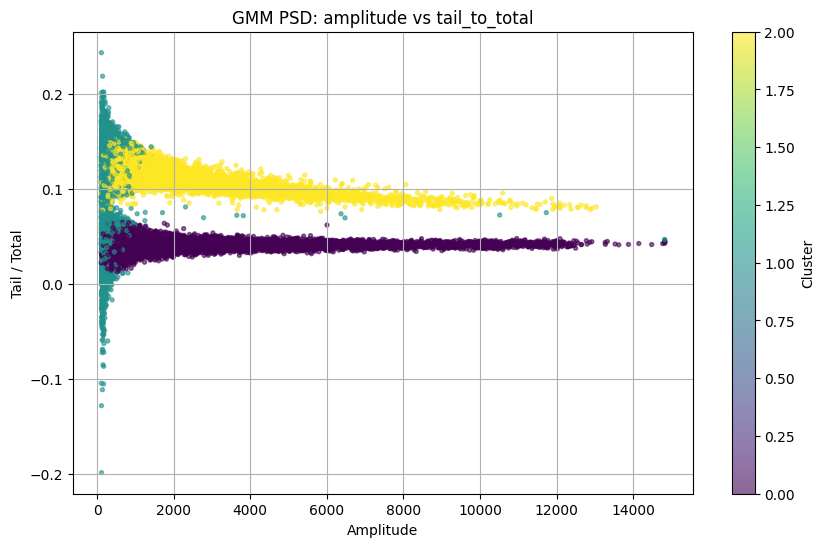

In [25]:
plt.figure(figsize=(10, 6))

plt.scatter(
    features["amplitude"],
    features["tail_to_total"],
    c=features["cluster_gmm_psd"],
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.title("GMM PSD: amplitude vs tail_to_total")
plt.xlabel("Amplitude")
plt.ylabel("Tail / Total")
plt.grid(True)
plt.colorbar(label="Cluster")
plt.show()

На графике видно, что GMM разделяет сигналы по доле хвостовой компоненты.  
Кластер 0 соответствует сигналам с меньшим значением tail_to_total, кластер 2 - сигналам с большей долей хвостовой части, а кластер 1 в основном расположен в области малых амплитуд.

Это подтверждает, что тестовая финальная модель учитывает не только величину сигнала, но и его форму.

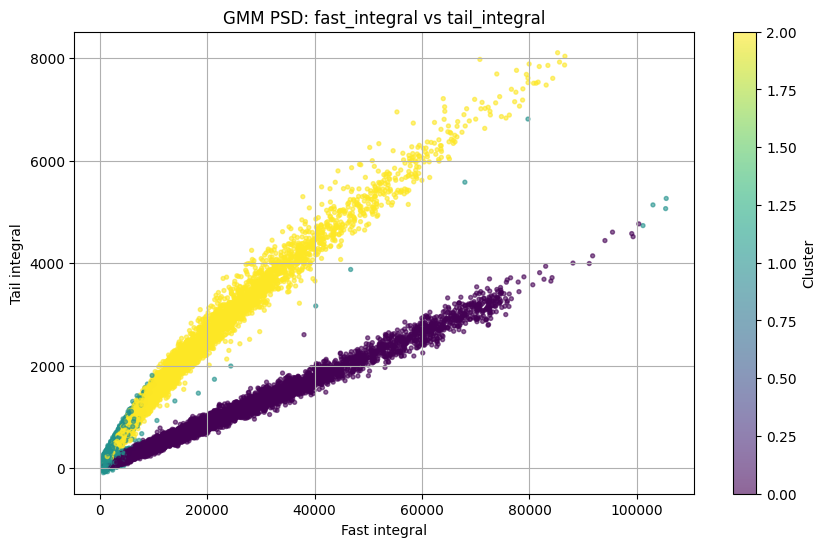

In [26]:
plt.figure(figsize=(10, 6))

plt.scatter(
    features["fast_integral"],
    features["tail_integral"],
    c=features["cluster_gmm_psd"],
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.title("GMM PSD: fast_integral vs tail_integral")
plt.xlabel("Fast integral")
plt.ylabel("Tail integral")
plt.grid(True)
plt.colorbar(label="Cluster")
plt.show()

График "fast_integral vs tail_integral" показывает две выраженные ветви сигналов.  
GMM PSD хорошо разделяет эти ветви: один кластер соответствует сигналам с меньшей хвостовой компонентой, другой - сигналам с более выраженным хвостом.

Такое разделение согласуется с идеей PSD-анализа, где типы частиц различаются по форме импульса и соотношению быстрой и хвостовой частей сигнала.

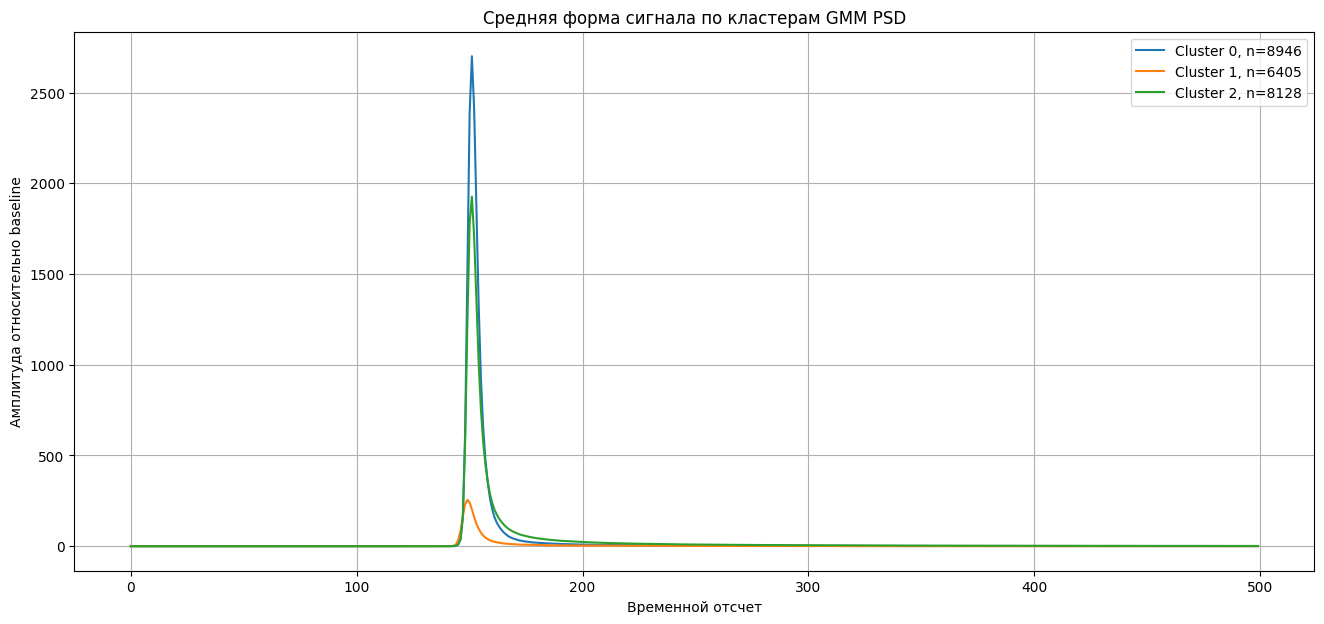

In [27]:
# Средняя форма сигналов по кластерам GMM PSD

plt.figure(figsize=(16, 7))

for cluster in sorted(features["cluster_gmm_psd"].unique()):
    cluster_indices = features.index[features["cluster_gmm_psd"] == cluster]
    mean_cluster_signal = signals_processed.loc[cluster_indices].mean(axis=0)

    plt.plot(
        x_axis,
        mean_cluster_signal.values,
        label=f"Cluster {cluster}, n={len(cluster_indices)}"
    )

plt.title("Средняя форма сигнала по кластерам GMM PSD")
plt.xlabel("Временной отсчет")
plt.ylabel("Амплитуда относительно baseline")
plt.legend()
plt.grid(True)
plt.show()

Средние формы сигналов по кластерам показывают, что все группы имеют пик примерно в одной временной области, но отличаются по амплитуде и характеру хвостовой части.

Кластер 0 имеет наиболее выраженную среднюю амплитуду и меньшую относительную долю хвоста.  
Кластер 2 характеризуется более заметной хвостовой компонентой.  
Кластер 1 имеет существенно меньшую среднюю амплитуду, что подтверждает его интерпретацию как группы слабых или пограничных сигналов.

Эти различия подтверждают корректность использования PSD-признаков для тестовой финальной кластеризации.

## Сравнение моделей

В ходе работы было протестировано несколько подходов к кластеризации сигналов. Экспериментальная часть выполнялась в отдельных ноутбуках.

Были рассмотрены следующие модели:

1. KMeans;
2. IsolationForest + GMM;
3. GMM на расширенном наборе признаков;
4. GMM на PSD-признаках.

Модель KMeans показала ограниченное качество, так как была склонна разделять сигналы преимущественно по амплитуде, а не по форме импульса.

Подход IsolationForest + GMM позволял выделять аномальные сигналы, однако формировал слишком малый аномальный кластер и хуже отражал общую структуру данных.

GMM на расширенном наборе признаков учитывал как амплитудные, так и интегральные характеристики, но часть признаков была сильно скоррелирована между собой, что снижало устойчивость кластеризации.

Наилучший результат показала модель Gaussian Mixture Model, обученная на PSD-признаках:

- tail_to_total;
- tail_to_fast;
- integral_to_amplitude.

Эти признаки описывают форму импульса и соотношение быстрой и хвостовой компонент сигнала. Поэтому они лучше подходят для разделения сигналов разных типов, чем признаки, связанные только с амплитудой.

В качестве тестовой итоговой модели была выбрана GMM на PSD-признаках, так как она дала наиболее интерпретируемое разделение кластеров и лучший результат на Kaggle на ранних экспериментах.

# Формирование итогового submission

Так как задача оценивается метрикой "accuracy", важен не только состав полученных кластеров, но и соответствие номеров кластеров истинным меткам.  
Алгоритмы кластеризации присваивают номера кластеров произвольно, поэтому после обучения модели необходимо выполнить перенумерацию кластеров.

Для финальной модели GMM на PSD-признаках лучший результат на Kaggle был получен при следующем соответствии:

```python
{0: 1, 1: 2, 2: 0}

In [28]:
# Создание файла submission

best_mapping = {
    0: 1,
    1: 2,
    2: 0
}

features["cluster_final"] = (
    features["cluster_gmm_psd"]
    .map(best_mapping)
    .astype(int)
)

print("Best mapping:", best_mapping)

print("\nРазмеры финальных кластеров:")
print(features["cluster_final"].value_counts().sort_index())

submission_final = pd.DataFrame({
    "index": features.index,
    "cluster": features["cluster_final"].values
})

print("\nРазмер submission:", submission_final.shape)
display(submission_final.head())
display(submission_final.tail())

submission_final.to_csv("submission_final.csv", index=False)

Best mapping: {0: 1, 1: 2, 2: 0}

Размеры финальных кластеров:
cluster_final
0    8128
1    8946
2    6405
Name: count, dtype: int64

Размер submission: (23479, 2)


,index,cluster
0,0,2
1,1,1
2,2,1
3,3,0
4,4,1


,index,cluster
23474,23474,1
23475,23475,0
23476,23476,0
23477,23477,0
23478,23478,1


In [29]:
assert submission_final.shape == (23479, 2)
assert list(submission_final.columns) == ["index", "cluster"]
assert set(submission_final["cluster"].unique()) == {0, 1, 2}
assert submission_final["index"].is_monotonic_increasing

print("Файл submission_final.csv успешно сформирован.")
print(submission_final["cluster"].value_counts().sort_index())

Файл submission_final.csv успешно сформирован.
cluster
0    8128
1    8946
2    6405
Name: count, dtype: int64


In [ ]:
from google.colab import files

files.download("submission_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>